# Analyze results

This is a live, executable version of the analysis you'd do in the app's embedded
notebook. It loads a small **sample recorder dataset** shipped with these docs — the
voltage magnitudes from the *NLR DSSE IEEE 123* example — and reproduces the kind of
plots you see on the [results page](run-a-template.md).

When you run your own simulation, the app writes the same kind of Feather files to the
run's `build/` directory and points the notebook's `DATA_DIR` at it.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample recorder output committed with the docs. In the app, this would be
# DATA_DIR = <run>/build and you would read the recorder Feather files there.
DATA_DIR = Path("../data/sample_results")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/sample_results")

estimated = pd.read_feather(DATA_DIR / "voltage_mag.feather")
true = pd.read_feather(DATA_DIR / "true_voltage_mag.feather")
estimated.shape, true.shape

((5, 279), (6, 279))

Each row is a timestep and each column is a bus (e.g. `150.1` is phase 1 of bus 150).
A `time` column carries the timestamp. Let's split the timestamps from the bus columns.

In [2]:
def bus_columns(df):
    return [c for c in df.columns if c != "time"]

buses = [c for c in bus_columns(estimated) if c in set(bus_columns(true))]
print(f"{len(buses)} common buses, {len(estimated)} estimated timesteps")
estimated[buses].iloc[:, :5].head()

278 common buses, 5 estimated timesteps


,150.1,150.2,150.3,150R.1,150R.2
0,2454.481106,2454.481106,2454.481106,2454.481106,2454.481106
1,2454.481106,2454.481106,2454.481106,2454.481106,2454.481106
2,2454.481106,2454.481106,2454.481106,2454.481106,2454.481106
3,2454.481106,2454.481106,2454.481106,2454.481106,2454.481106
4,2454.481106,2454.481106,2454.481106,2454.481106,2454.481106


## Voltage profile across the feeder

Plot the voltage magnitude at every bus for a single timestep — the estimated values
against the true values from the feeder.

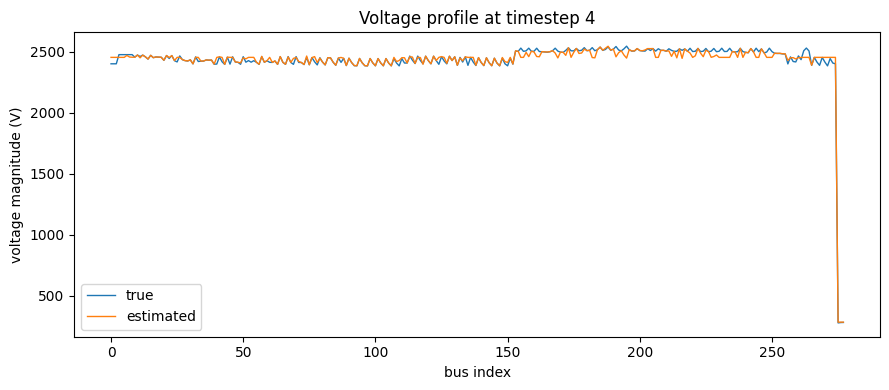

In [3]:
t = min(len(estimated), len(true)) - 1  # last common timestep

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(buses)), true.loc[t, buses].to_numpy(float), label="true", lw=1)
ax.plot(range(len(buses)), estimated.loc[t, buses].to_numpy(float), label="estimated", lw=1)
ax.set(xlabel="bus index", ylabel="voltage magnitude (V)",
       title=f"Voltage profile at timestep {t}")
ax.legend()
fig.tight_layout()

## Estimated vs. true

A state estimator should land close to the true values. Plotting estimated against true
should cluster along the diagonal; the **mean absolute relative error (MARE)** — the same
metric the app reports — quantifies the gap.

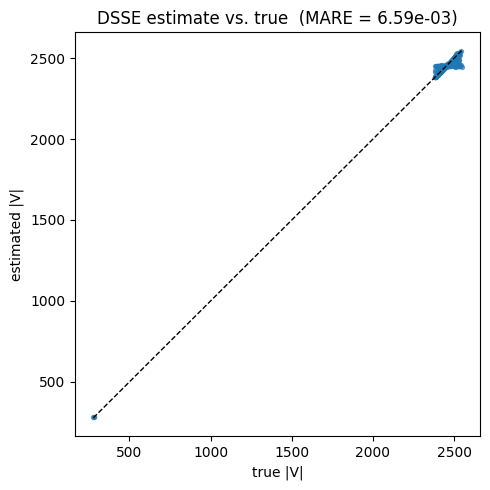

In [4]:
x = true.loc[t, buses].to_numpy(float)
y = estimated.loc[t, buses].to_numpy(float)
mare = np.mean(np.abs(y - x) / np.abs(x))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, s=8, alpha=0.6)
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xlabel="true |V|", ylabel="estimated |V|",
       title=f"DSSE estimate vs. true  (MARE = {mare:.2e})")
fig.tight_layout()

## Try it on your own runs

Run any template from the [Saved Templates](run-a-template.md) page, open its
**Notebook**, and set `DATA_DIR` to the run's `build/` directory. The recorder Feather
files there have exactly the columns used above, so this analysis carries over unchanged.